# Notebook 01 — PaySim Dataset Exploration

**Objectives:**
- Understand raw PaySim dataset structure and statistics
- Visualize class imbalance and justify exclusion of Accuracy
- Analyze transaction amount distributions
- Explore fraud patterns by transaction type
- Examine temporal transaction behavior
- Validate engineered features (errorBalanceOrig / errorBalanceDest)

**Confirmed dataset stats (from prepare_data.py):**
- Total records: 6,362,620
- Train: 5,090,096 | Test: 1,272,524
- Global test fraud: 1,643 cases

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams.update({'figure.dpi': 150, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.figsize': (11, 6)})

FIGURES_DIR = Path('../notebooks/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RAW_DATA_PATH = '../data/raw/paysim.csv'

print('Imports complete. ✓')

Imports complete. ✓


In [13]:
df = pd.read_csv(RAW_DATA_PATH)

print(f'Dataset shape     : {df.shape}')
print(f'Total records     : {len(df):,}')
print(f'Total columns     : {df.shape[1]}')
print(f'\nColumn names:\n{list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')

Dataset shape     : (6362620, 11)
Total records     : 6,362,620
Total columns     : 11

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [14]:
total       = len(df)
fraud_count = int(df['isFraud'].sum())
legit_count = total - fraud_count
fraud_pct   = fraud_count / total * 100
legit_pct   = 100 - fraud_pct

print('=' * 60)
print('  BASIC DATASET STATISTICS')
print('=' * 60)
print(f'\n  Total transactions  : {total:>12,}')
print(f'  Legitimate          : {legit_count:>12,}  ({legit_pct:.4f}%)')
print(f'  Fraudulent          : {fraud_count:>12,}  ({fraud_pct:.4f}%)')
print(f'  Imbalance ratio     : {legit_count // fraud_count:>12,} : 1')
print(f'\n  Missing values:\n{df.isnull().sum()}')
print(f'\n  Amount statistics:')
print(df['amount'].describe().to_string())

  BASIC DATASET STATISTICS

  Total transactions  :    6,362,620
  Legitimate          :    6,354,407  (99.8709%)
  Fraudulent          :        8,213  (0.1291%)
  Imbalance ratio     :          773 : 1

  Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

  Amount statistics:
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07


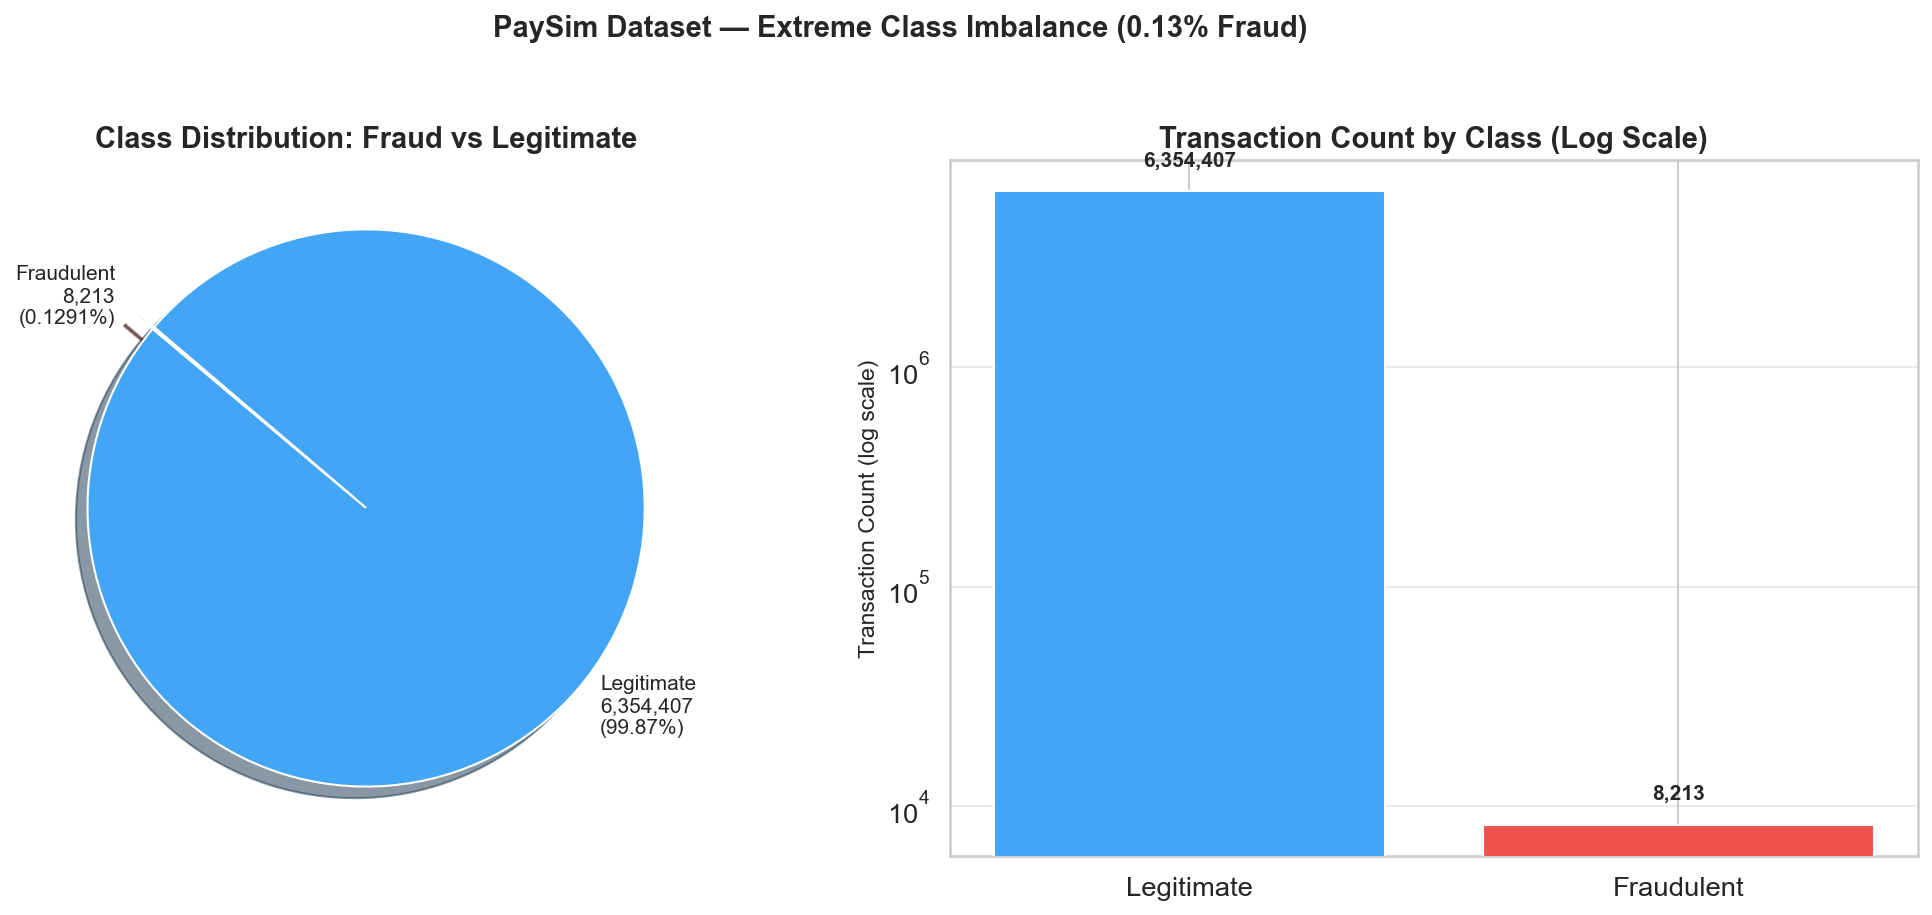

Figure saved → class_imbalance.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels  = [f'Legitimate\n{legit_count:,}\n({legit_pct:.2f}%)',
           f'Fraudulent\n{fraud_count:,}\n({fraud_pct:.4f}%)']
colors  = ['#42A5F5', '#EF5350']
explode = [0, 0.08]

axes[0].pie([legit_count, fraud_count], labels=labels, colors=colors,
            explode=explode, startangle=140, shadow=True,
            textprops={'fontsize': 10})
axes[0].set_title('Class Distribution: Fraud vs Legitimate', fontweight='bold')

bars = axes[1].bar(['Legitimate', 'Fraudulent'], [legit_count, fraud_count],
                   color=colors, edgecolor='white', zorder=3)
axes[1].set_yscale('log')
axes[1].set_ylabel('Transaction Count (log scale)', fontsize=11)
axes[1].set_title('Transaction Count by Class (Log Scale)', fontweight='bold')
for bar, count in zip(bars, [legit_count, fraud_count]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.3,
                 f'{count:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('PaySim Dataset — Extreme Class Imbalance (0.13% Fraud)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → class_imbalance.png')

  ACCURACY EXCLUSION JUSTIFICATION

  Degenerate classifier accuracy = 99.8709%
  (predicts Legitimate for EVERY transaction)
  Fraud detected = 0  →  Accuracy is EXCLUDED throughout this thesis.


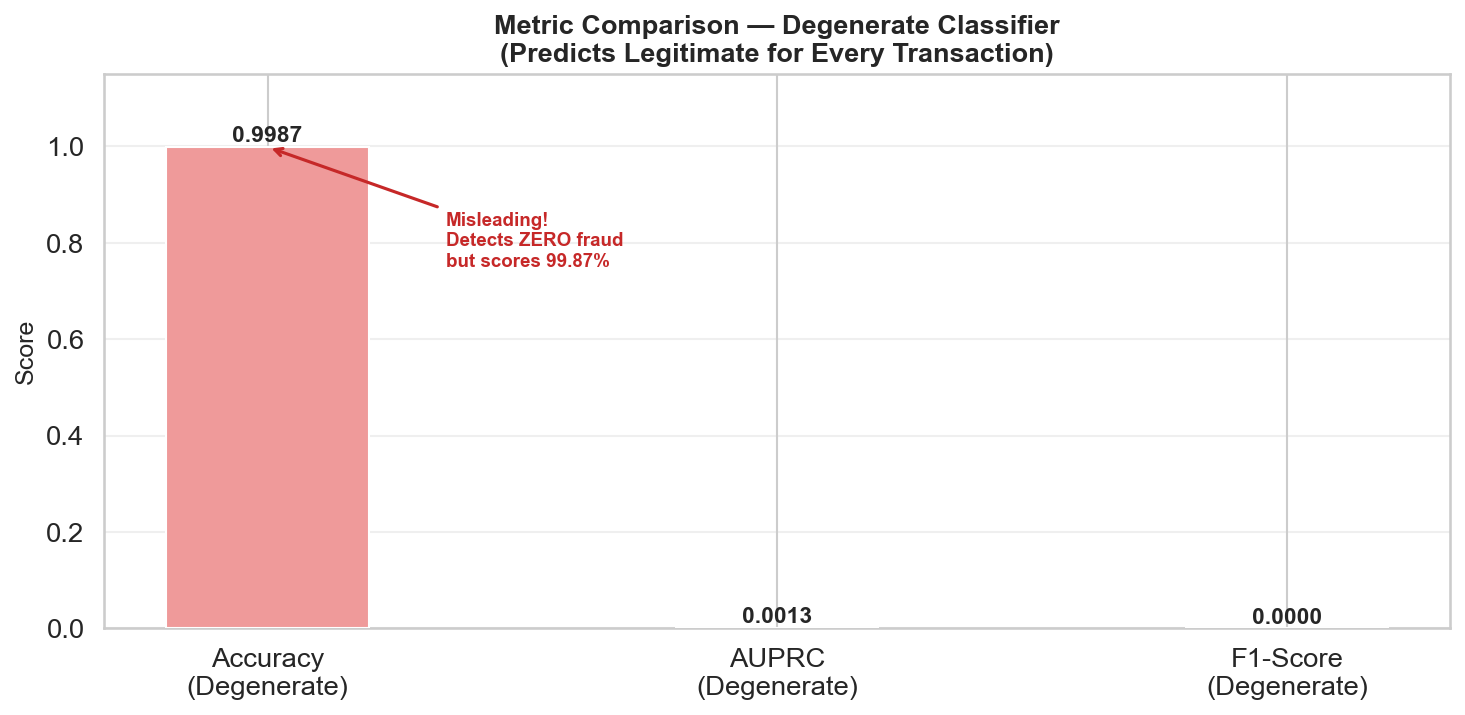

Figure saved → accuracy_exclusion_justification.png


In [16]:
# Why accuracy is excluded
degenerate_accuracy = legit_count / total * 100

print('=' * 60)
print('  ACCURACY EXCLUSION JUSTIFICATION')
print('=' * 60)
print(f'\n  Degenerate classifier accuracy = {degenerate_accuracy:.4f}%')
print(f'  (predicts Legitimate for EVERY transaction)')
print(f'  Fraud detected = 0  →  Accuracy is EXCLUDED throughout this thesis.')

fig, ax = plt.subplots(figsize=(10, 5))
metric_names = ['Accuracy\n(Degenerate)', 'AUPRC\n(Degenerate)', 'F1-Score\n(Degenerate)']
metric_vals  = [degenerate_accuracy / 100, 0.0013, 0.0]
bar_colors   = ['#EF9A9A', '#42A5F5', '#42A5F5']

bars = ax.bar(metric_names, metric_vals, color=bar_colors,
              edgecolor='white', zorder=3, width=0.4)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metric Comparison — Degenerate Classifier\n'
             '(Predicts Legitimate for Every Transaction)',
             fontsize=13, fontweight='bold')
ax.annotate('Misleading!\nDetects ZERO fraud\nbut scores 99.87%',
            xy=(0, degenerate_accuracy/100), xytext=(0.35, 0.75),
            fontsize=9, color='#C62828', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_exclusion_justification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → accuracy_exclusion_justification.png')

Fraud distribution by transaction type:
    type   total  fraud  fraud_pct   legit
 CASH_IN 1399284      0   0.000000 1399284
CASH_OUT 2237500   4116   0.183955 2233384
   DEBIT   41432      0   0.000000   41432
 PAYMENT 2151495      0   0.000000 2151495
TRANSFER  532909   4097   0.768799  528812


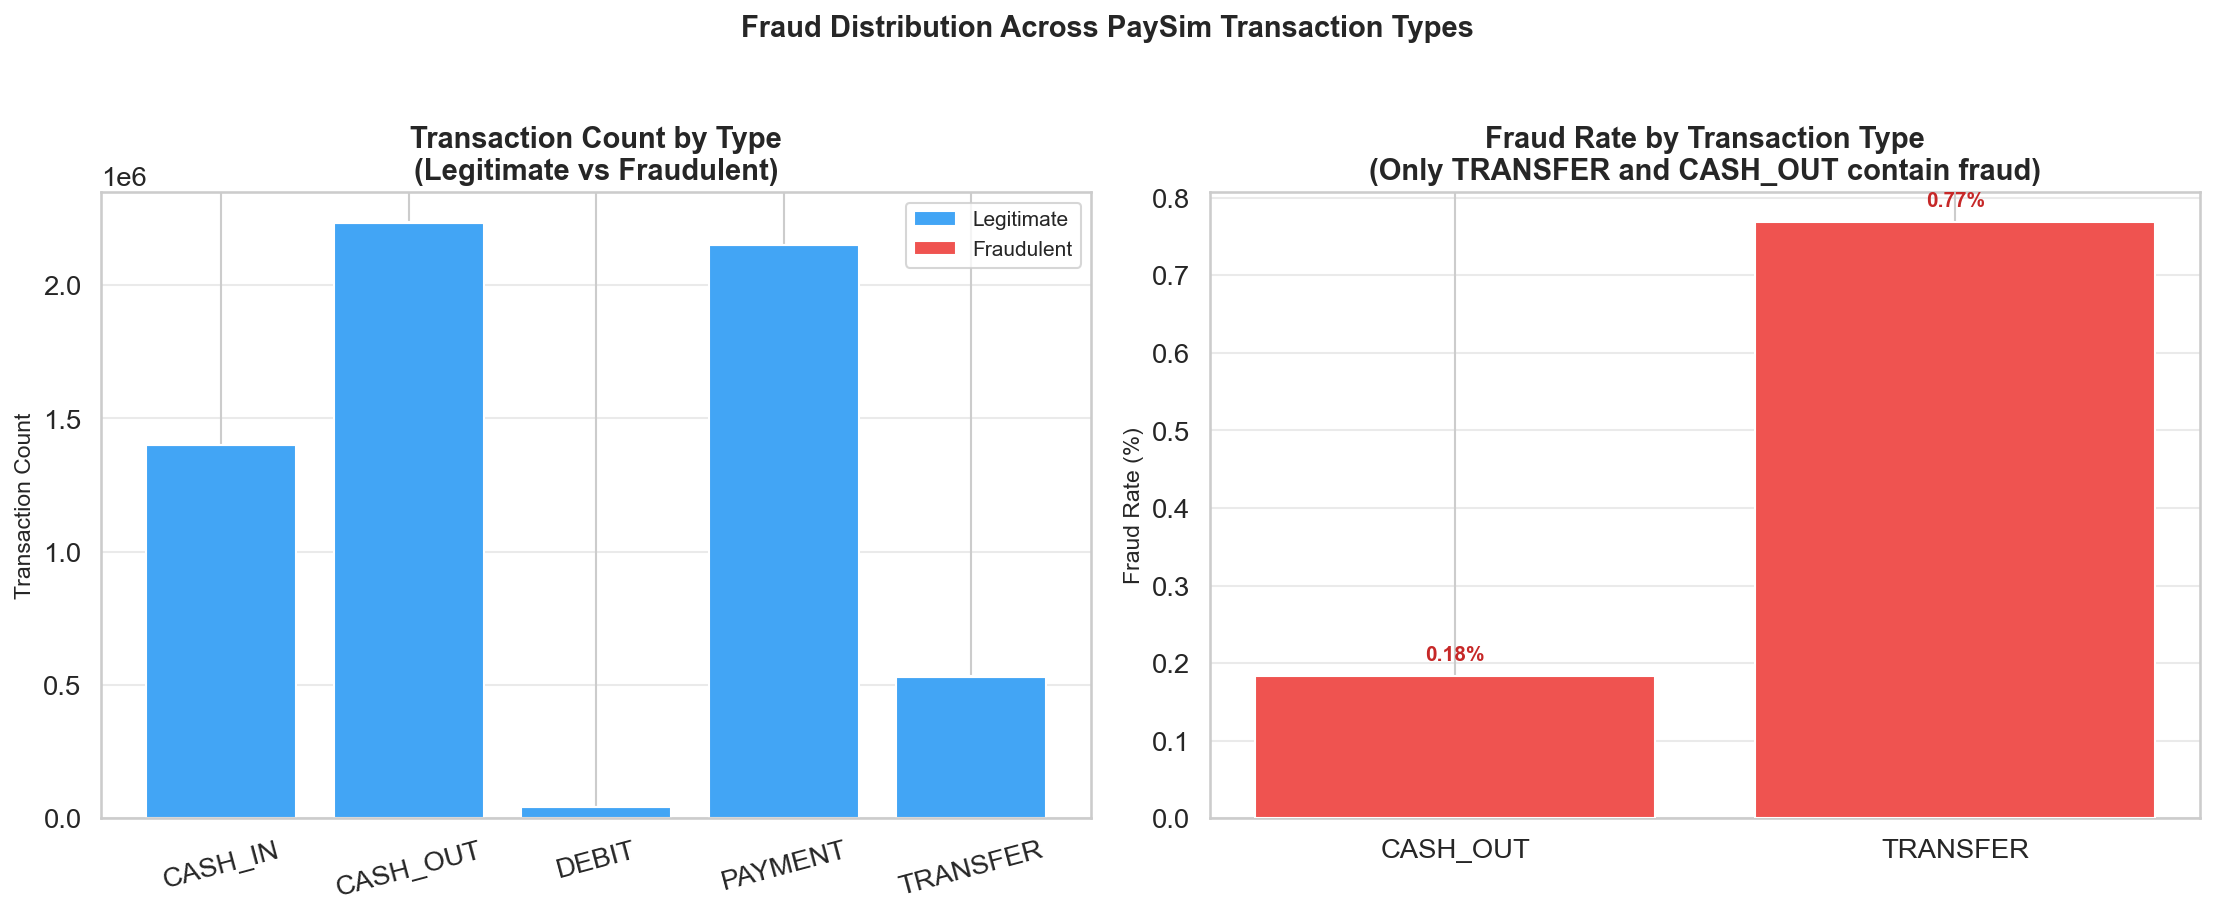

Figure saved → fraud_by_transaction_type.png


In [17]:
type_summary = df.groupby('type').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
).reset_index()
type_summary['fraud_pct'] = type_summary['fraud'] / type_summary['total'] * 100
type_summary['legit']     = type_summary['total'] - type_summary['fraud']

print('Fraud distribution by transaction type:')
print(type_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(type_summary['type'], type_summary['legit'],
            label='Legitimate', color='#42A5F5', edgecolor='white')
axes[0].bar(type_summary['type'], type_summary['fraud'],
            bottom=type_summary['legit'], label='Fraudulent',
            color='#EF5350', edgecolor='white')
axes[0].set_ylabel('Transaction Count', fontsize=11)
axes[0].set_title('Transaction Count by Type\n(Legitimate vs Fraudulent)', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.4)

fraud_only = type_summary[type_summary['fraud'] > 0]
bars = axes[1].bar(fraud_only['type'], fraud_only['fraud_pct'],
                   color='#EF5350', edgecolor='white', zorder=3)
for bar, val in zip(bars, fraud_only['fraud_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}%', ha='center', fontsize=10,
                 fontweight='bold', color='#C62828')
axes[1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[1].set_title('Fraud Rate by Transaction Type\n'
                  '(Only TRANSFER and CASH_OUT contain fraud)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Fraud Distribution Across PaySim Transaction Types',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fraud_by_transaction_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → fraud_by_transaction_type.png')

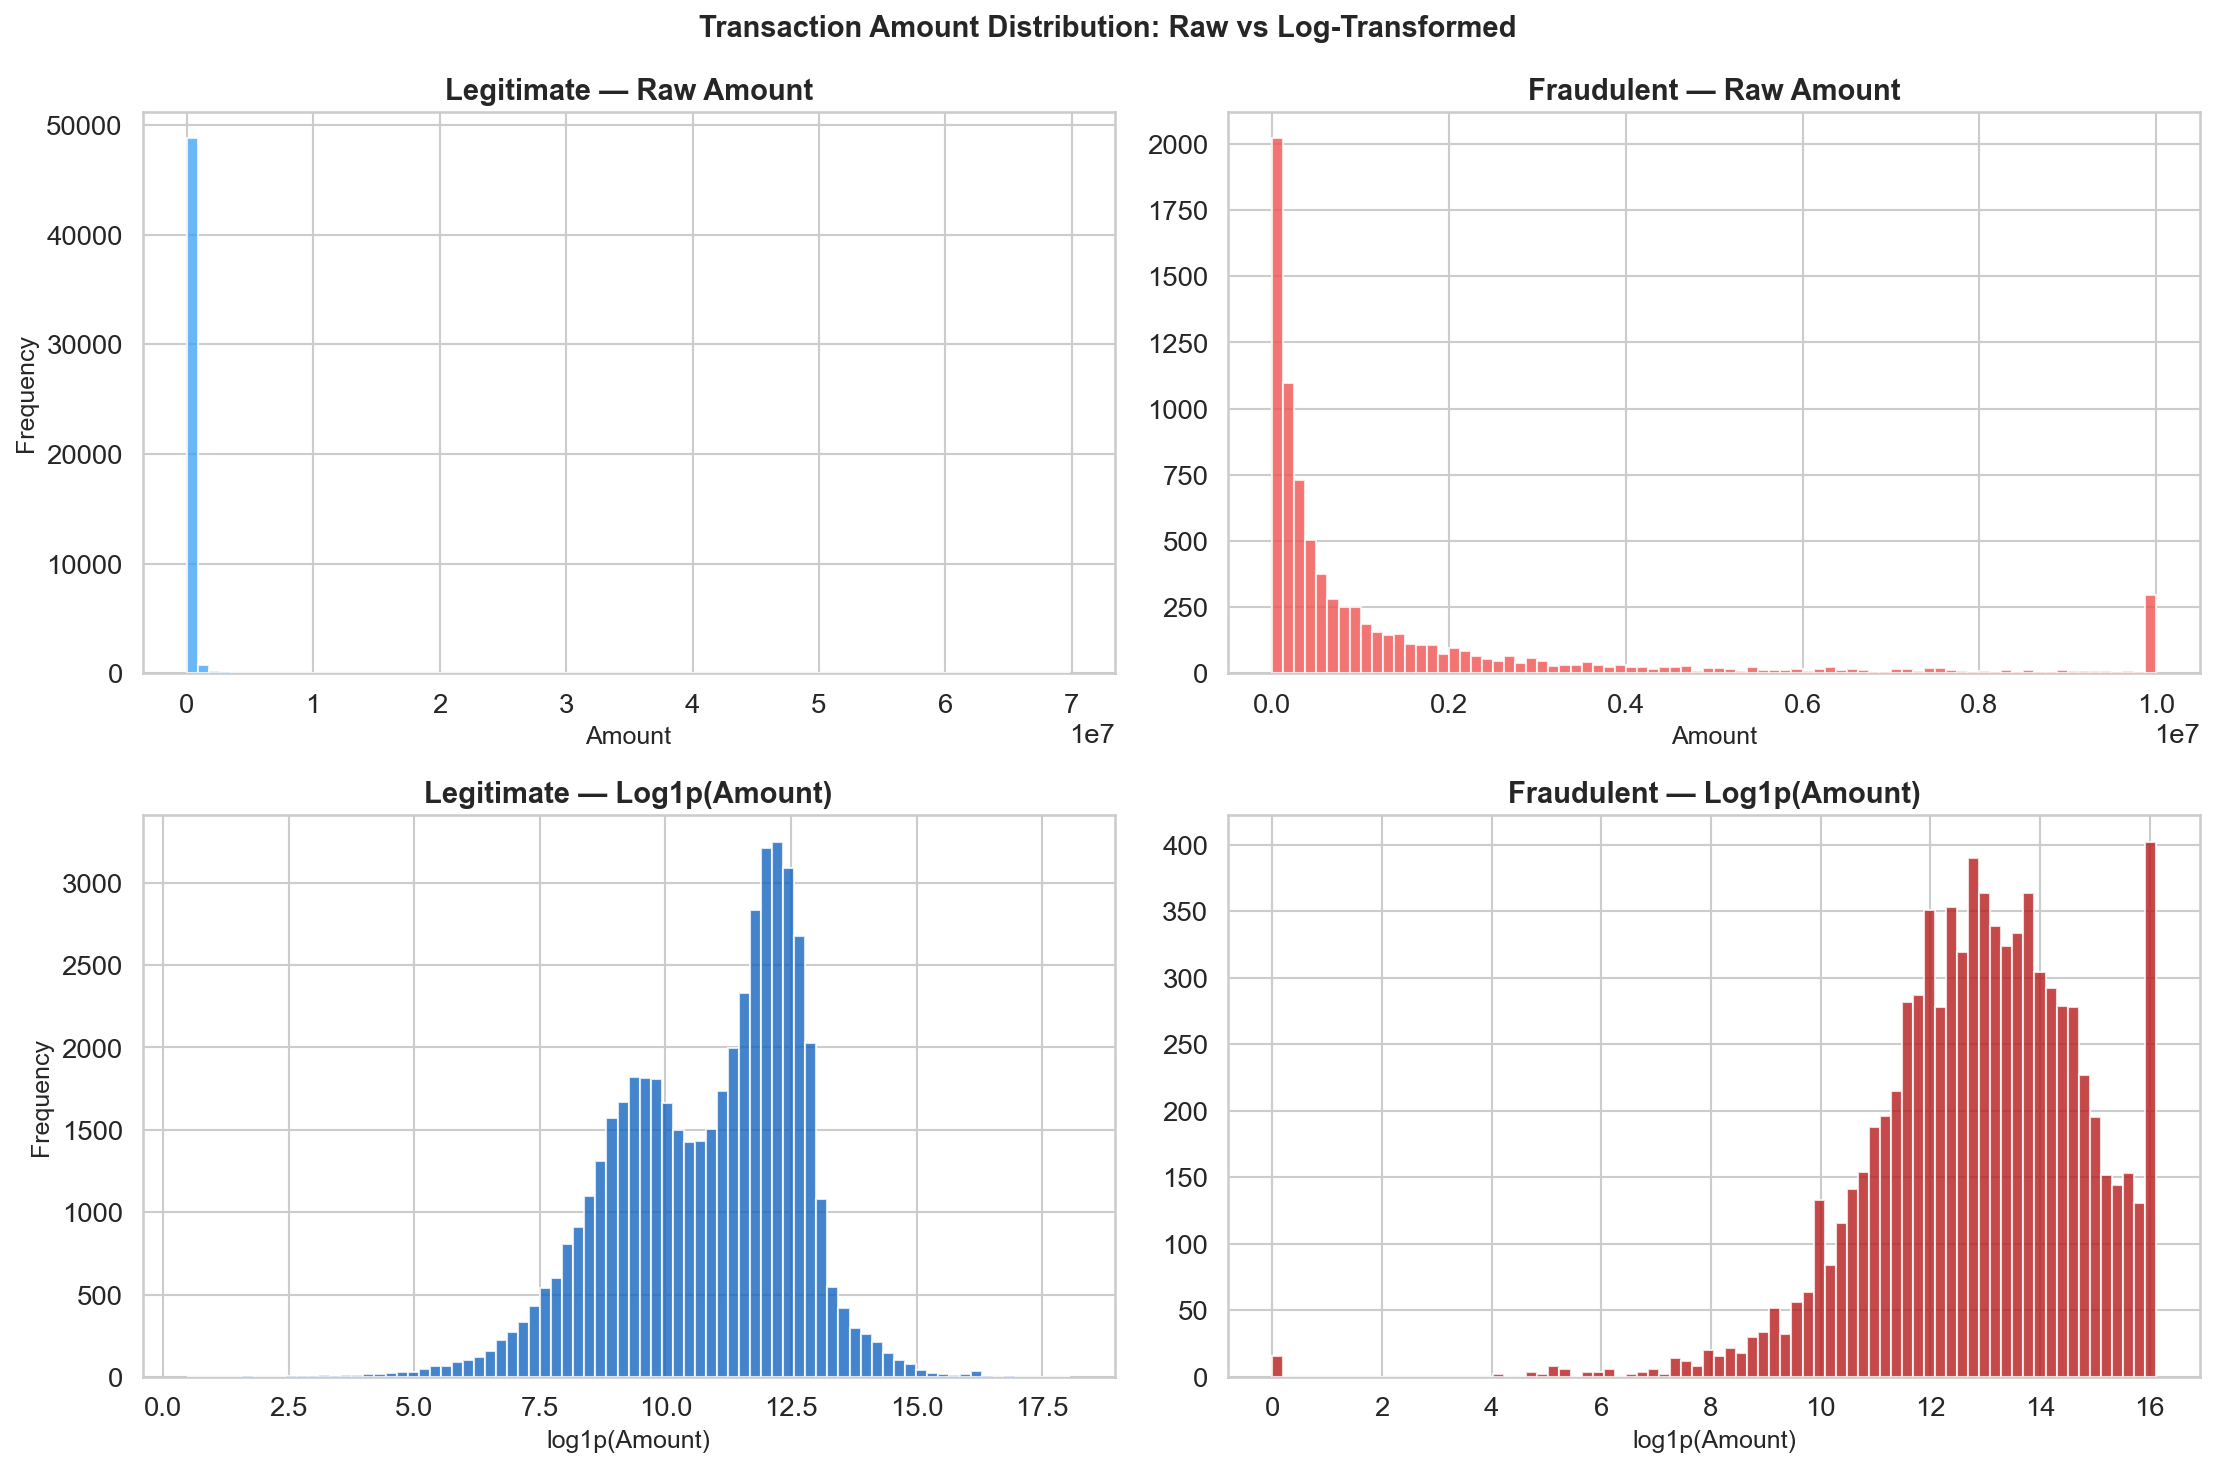

Figure saved → amount_distribution.png


In [18]:
fraud_amounts = df[df['isFraud'] == 1]['amount']
legit_amounts = df[df['isFraud'] == 0]['amount'].sample(n=50000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(legit_amounts, bins=80, color='#42A5F5', edgecolor='white', alpha=0.8, zorder=3)
axes[0,0].set_title('Legitimate — Raw Amount', fontweight='bold')
axes[0,0].set_xlabel('Amount')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(fraud_amounts, bins=80, color='#EF5350', edgecolor='white', alpha=0.8, zorder=3)
axes[0,1].set_title('Fraudulent — Raw Amount', fontweight='bold')
axes[0,1].set_xlabel('Amount')

axes[1,0].hist(np.log1p(legit_amounts), bins=80, color='#1565C0',
               edgecolor='white', alpha=0.8, zorder=3)
axes[1,0].set_title('Legitimate — Log1p(Amount)', fontweight='bold')
axes[1,0].set_xlabel('log1p(Amount)')
axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(np.log1p(fraud_amounts), bins=80, color='#B71C1C',
               edgecolor='white', alpha=0.8, zorder=3)
axes[1,1].set_title('Fraudulent — Log1p(Amount)', fontweight='bold')
axes[1,1].set_xlabel('log1p(Amount)')

plt.suptitle('Transaction Amount Distribution: Raw vs Log-Transformed',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → amount_distribution.png')

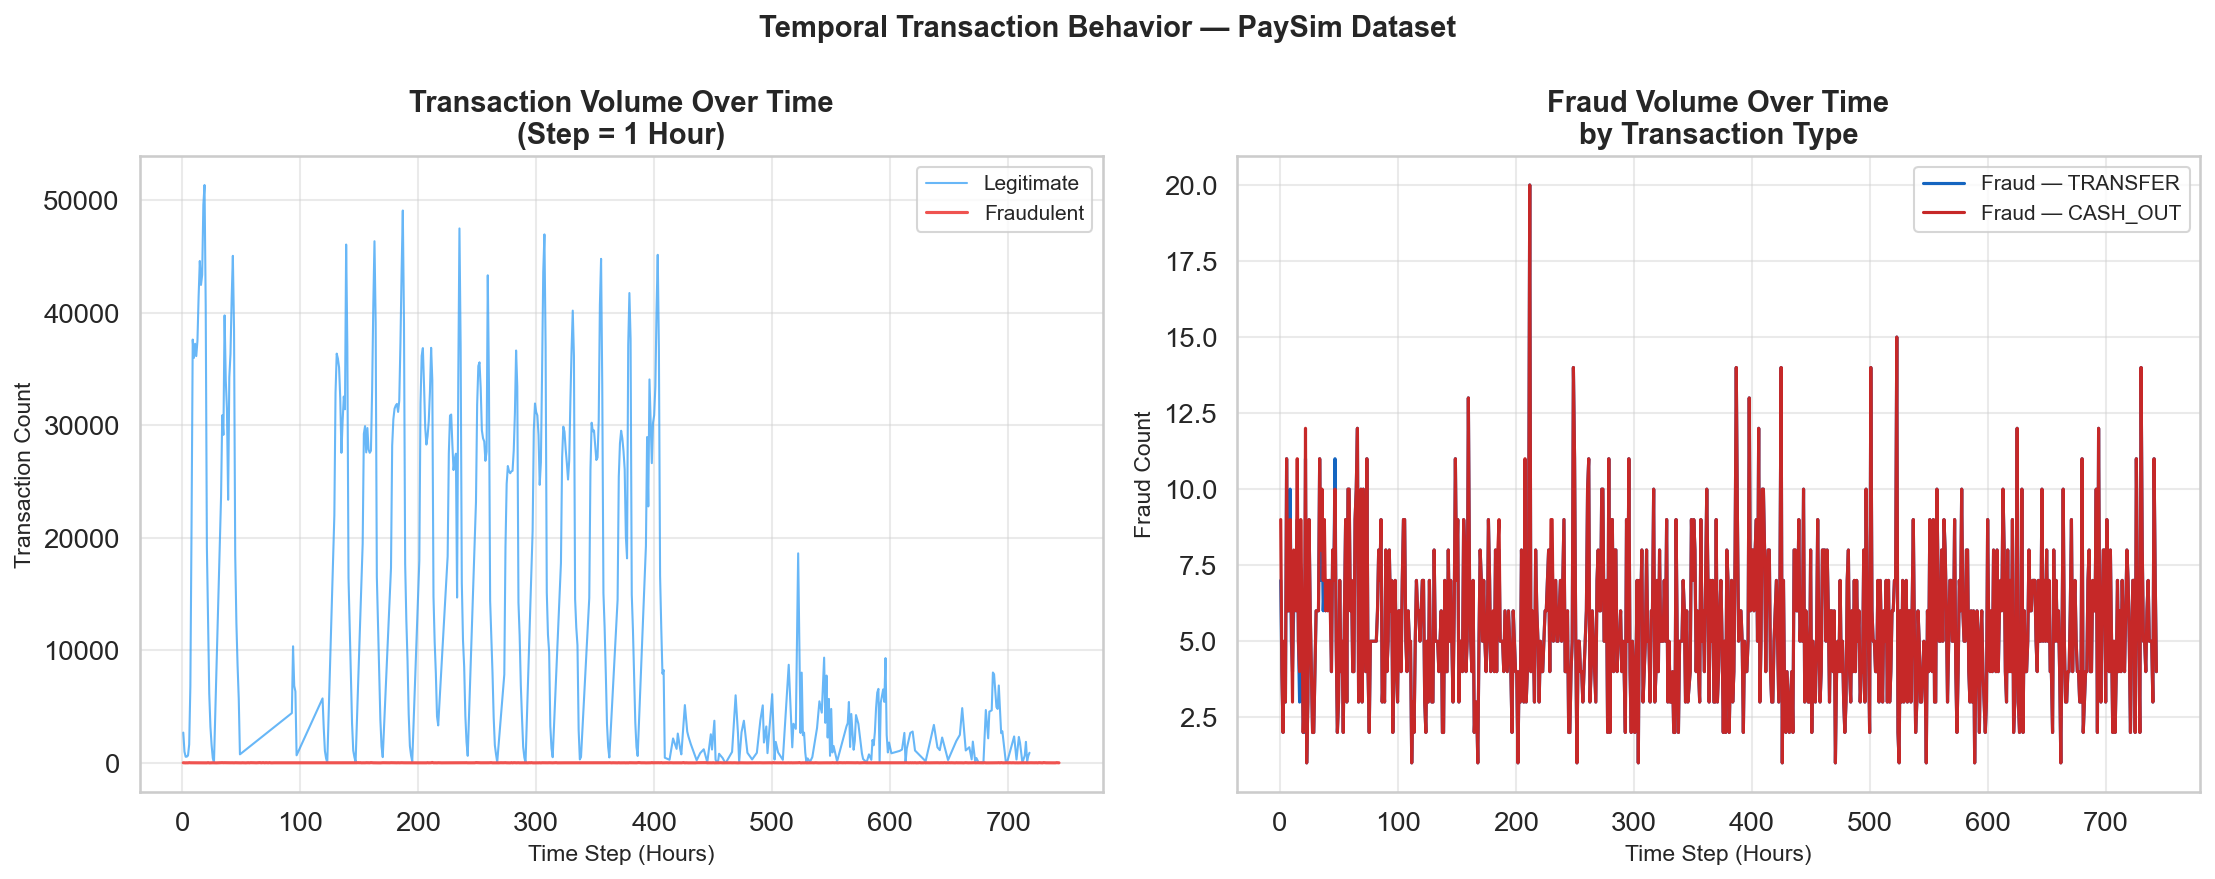

Figure saved → temporal_analysis.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fraud_by_step = df[df['isFraud']==1].groupby('step').size().reset_index(name='count')
legit_by_step = df[df['isFraud']==0].groupby('step').size().reset_index(name='count')

axes[0].plot(legit_by_step['step'], legit_by_step['count'],
             color='#42A5F5', linewidth=1.0, alpha=0.8, label='Legitimate')
axes[0].plot(fraud_by_step['step'], fraud_by_step['count'],
             color='#EF5350', linewidth=1.5, label='Fraudulent')
axes[0].set_xlabel('Time Step (Hours)', fontsize=11)
axes[0].set_ylabel('Transaction Count', fontsize=11)
axes[0].set_title('Transaction Volume Over Time\n(Step = 1 Hour)', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

for tx_type, color in [('TRANSFER', '#1565C0'), ('CASH_OUT', '#C62828')]:
    type_fraud = (df[(df['isFraud']==1) & (df['type']==tx_type)]
                  .groupby('step').size().reset_index(name='count'))
    axes[1].plot(type_fraud['step'], type_fraud['count'],
                 color=color, linewidth=1.5, label=f'Fraud — {tx_type}')
axes[1].set_xlabel('Time Step (Hours)', fontsize=11)
axes[1].set_ylabel('Fraud Count', fontsize=11)
axes[1].set_title('Fraud Volume Over Time\nby Transaction Type', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Temporal Transaction Behavior — PaySim Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → temporal_analysis.png')

  ENGINEERED FEATURE ANALYSIS

  errorBalanceOrig:
    Fraud — mean:       10,692.33 | nonzero: 1.5%
    Legit — mean:      201,338.56 | nonzero: 85.2%

  errorBalanceDest:
    Fraud — mean:     -732,509.30 | nonzero: 64.8%
    Legit — mean:      -54,692.23 | nonzero: 74.5%


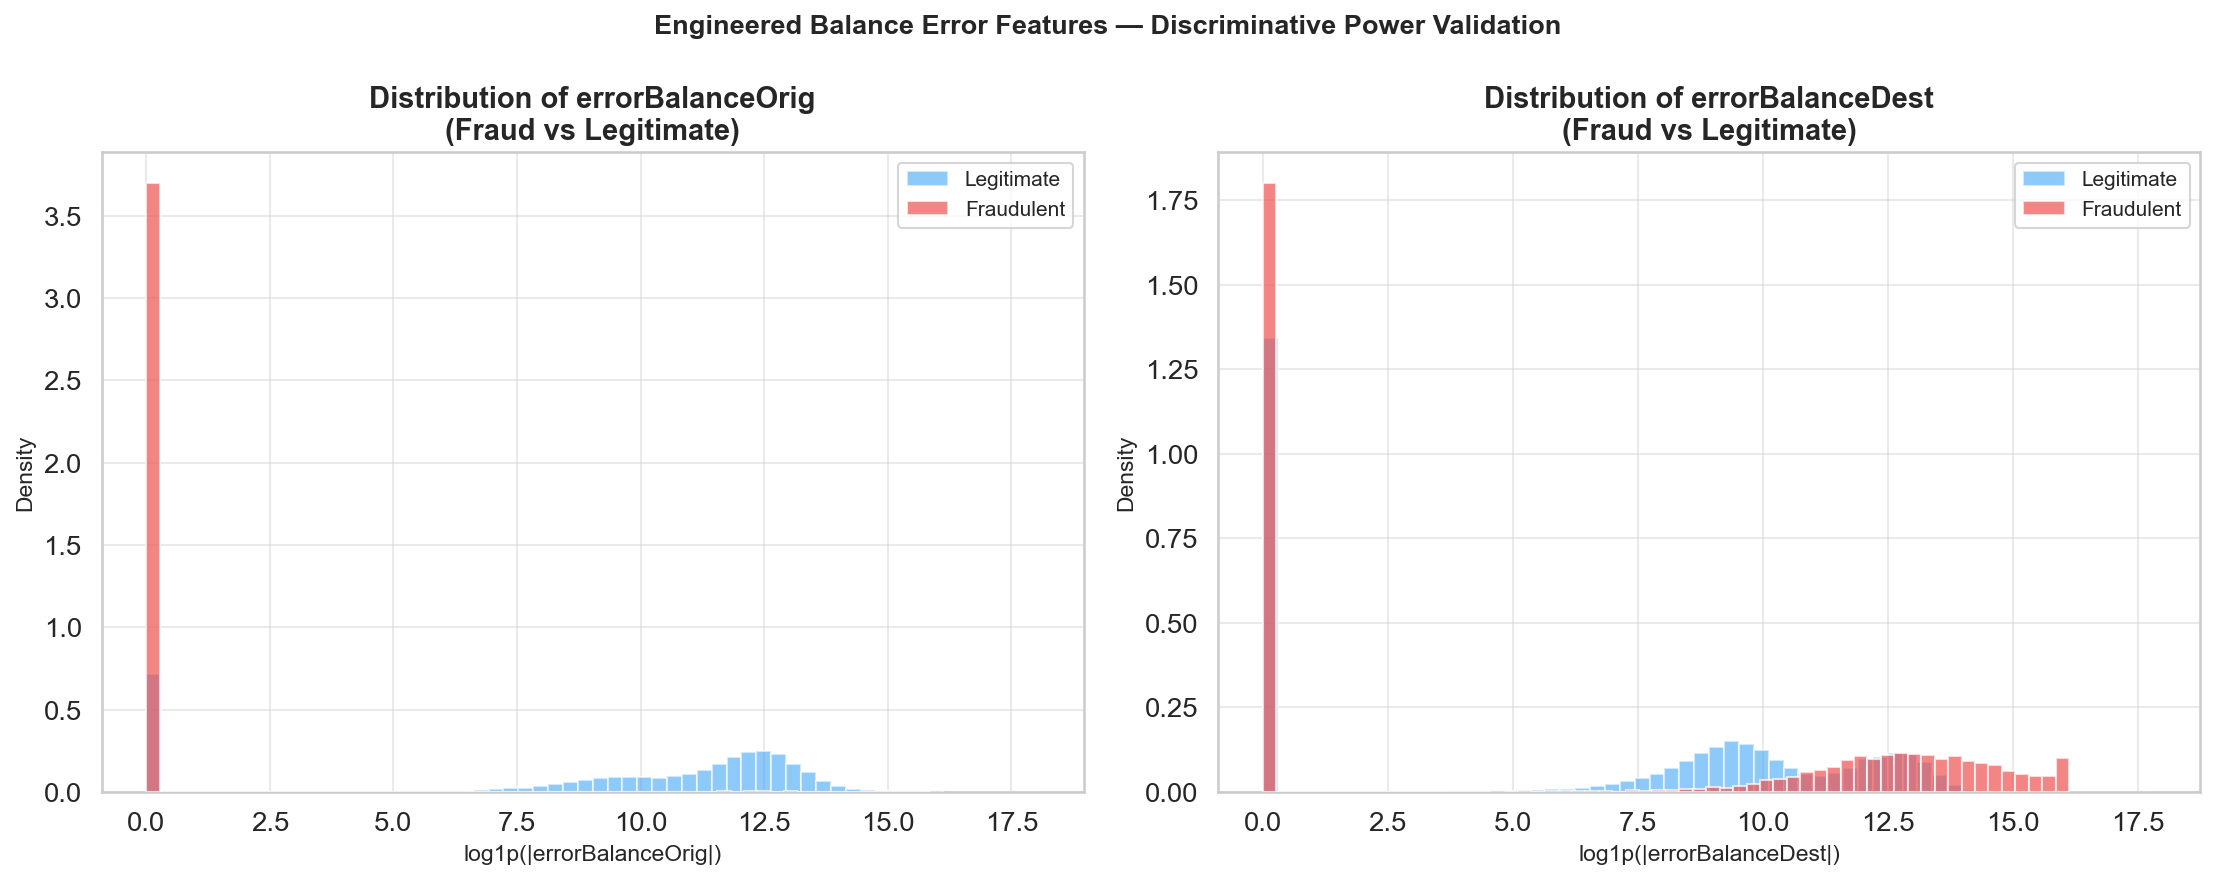

Figure saved → engineered_features_validation.png


In [20]:
df['errorBalanceOrig'] = df['newbalanceOrig'] - (df['oldbalanceOrg'] - df['amount'])
df['errorBalanceDest'] = df['newbalanceDest'] - (df['oldbalanceDest'] + df['amount'])

print('=' * 60)
print('  ENGINEERED FEATURE ANALYSIS')
print('=' * 60)
for feat in ['errorBalanceOrig', 'errorBalanceDest']:
    fraud_vals = df[df['isFraud']==1][feat]
    legit_vals = df[df['isFraud']==0][feat]
    print(f'\n  {feat}:')
    print(f'    Fraud — mean: {fraud_vals.mean():>15,.2f} | nonzero: {(fraud_vals!=0).mean()*100:.1f}%')
    print(f'    Legit — mean: {legit_vals.mean():>15,.2f} | nonzero: {(legit_vals!=0).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, feat in zip(axes, ['errorBalanceOrig', 'errorBalanceDest']):
    fraud_log = np.log1p(np.abs(df[df['isFraud']==1][feat]))
    legit_log = np.log1p(np.abs(df[df['isFraud']==0][feat].sample(n=50000, random_state=42)))
    ax.hist(legit_log, bins=60, color='#42A5F5', alpha=0.6, label='Legitimate', density=True, zorder=2)
    ax.hist(fraud_log, bins=60, color='#EF5350', alpha=0.7, label='Fraudulent', density=True, zorder=3)
    ax.set_xlabel(f'log1p(|{feat}|)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Distribution of {feat}\n(Fraud vs Legitimate)', fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

plt.suptitle('Engineered Balance Error Features — Discriminative Power Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'engineered_features_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → engineered_features_validation.png')

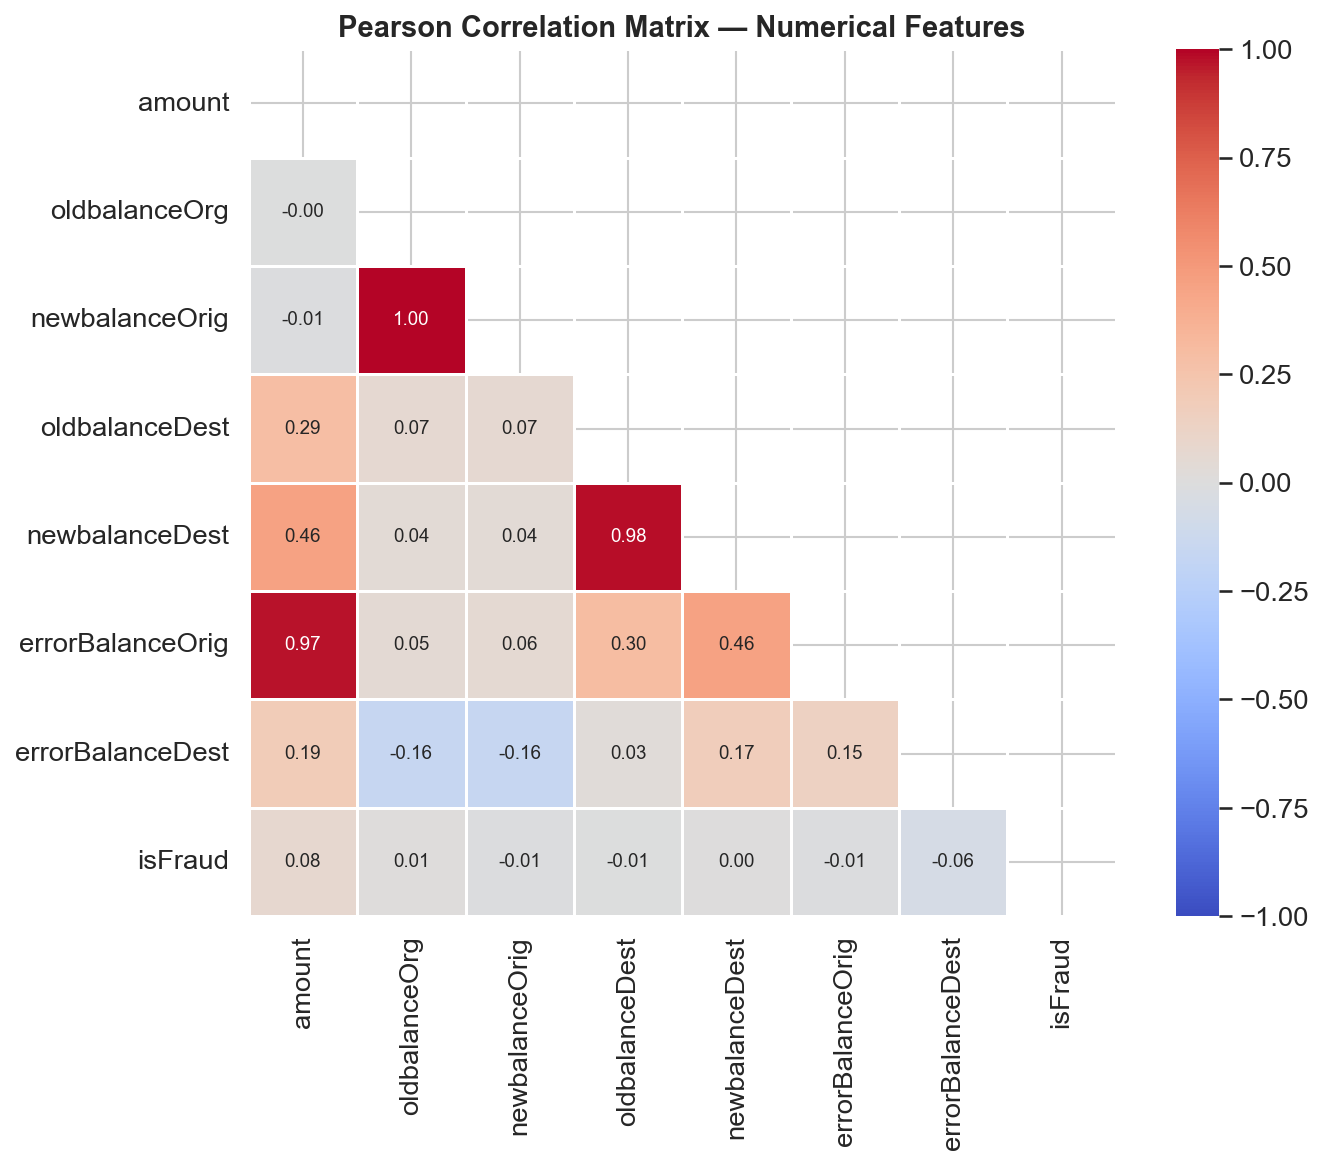

Figure saved → correlation_heatmap.png


In [21]:
num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest',
            'errorBalanceOrig', 'errorBalanceDest', 'isFraud']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Pearson Correlation Matrix — Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → correlation_heatmap.png')

In [22]:
print('\n' + '=' * 60)
print('  DATASET EXPLORATION SUMMARY (Confirmed Values)')
print('=' * 60)

summary = {
    'Total Records':         f'{total:,}',
    'Fraud Records':         f'{fraud_count:,}',
    'Legitimate Records':    f'{legit_count:,}',
    'Fraud Prevalence':      f'{fraud_pct:.4f}%',
    'Imbalance Ratio':       f'{legit_count // fraud_count:,} : 1',
    'Fraud-Bearing Types':   'TRANSFER, CASH_OUT only',
    'Global Test Set':       '1,272,524 records | 1,643 fraud',
    'Bank 1 Train':          '1,064,011 records | 3,077 fraud (0.2892%)',
    'Bank 2 Train':          '2,272,208 records | 0 fraud (0.0000%) — BLIND SPOT',
    'Bank 3 Train':          '735,859 records | 2,129 fraud (0.2893%)',
    'Accuracy Excluded':     'YES — degenerate classifier scores 99.87%',
    'Primary Metrics':       'AUPRC, F1-Score',
}
for k, v in summary.items():
    print(f'  {k:<28}: {v}')

print('\nNotebook 01 complete. ✓')


  DATASET EXPLORATION SUMMARY (Confirmed Values)
  Total Records               : 6,362,620
  Fraud Records               : 8,213
  Legitimate Records          : 6,354,407
  Fraud Prevalence            : 0.1291%
  Imbalance Ratio             : 773 : 1
  Fraud-Bearing Types         : TRANSFER, CASH_OUT only
  Global Test Set             : 1,272,524 records | 1,643 fraud
  Bank 1 Train                : 1,064,011 records | 3,077 fraud (0.2892%)
  Bank 2 Train                : 2,272,208 records | 0 fraud (0.0000%) — BLIND SPOT
  Bank 3 Train                : 735,859 records | 2,129 fraud (0.2893%)
  Accuracy Excluded           : YES — degenerate classifier scores 99.87%
  Primary Metrics             : AUPRC, F1-Score

Notebook 01 complete. ✓
